In [ ]:
import sys
import os

import jax
from jax import random
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from modules.kgd_functions import F_P, GradientKernel,KernelGradientDiscrepancy, k_imq, imq_scale_mixtures, MMD, recommended_kernel, matern_kernel
from modules.extensible_sampling import ExtensibleSampling

import import_ipynb
from lotka_volterra import gradL_ms,true_params

In [207]:
kernel_name = "recommended_kernel"

In [ ]:
def grad_log_q0(X):
    return -X

# no need of the function L because gradL is provided
def L(X):
    return 0 

gamma = 10.0
gradL = lambda X: gradL_ms(X,gamma)

scales_es = jnp.array([0.03,2.0])
k_es = lambda x,y: imq_scale_mixtures(x,y,scales_es)


ES = ExtensibleSampling(grad_log_q0, L, k_es, gradL=gradL)

In [ ]:
T = 25
d = 2

key = random.PRNGKey(2024)
key, subkey = random.split(key)
x0 = jnp.array(true_params) + 1e-1 * random.normal(subkey, d)

mean = jnp.array(true_params)  
cov = 0.1
n_samples = 4050
settings = [mean,cov,n_samples]


X_fin = ES.run_particles(key,x0,T,min_search_method = "prior_search",settings = settings)


Iteration: 10
Iteration: 20


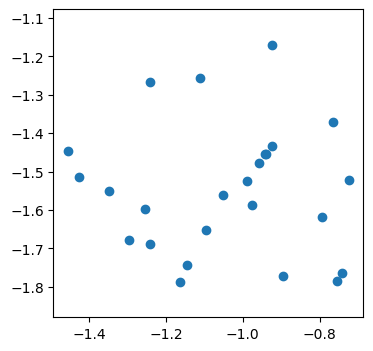

In [182]:
#plot final particles position 
plt.figure(figsize =(4,4))
plt.scatter(X_fin[:,0],X_fin[:,1],label='Final particles')
Y = random.multivariate_normal(key,jnp.zeros(2),np.eye(2),(100,2))
#plt.scatter(Y[:,0],Y[:,1],alpha=0.1,label='True distribution samples')
plt.axis('equal')
plt.show()


In [221]:
import jax.numpy as jnp
import pickle


expe3_filename_evol_particles = f"saved_data/expe3_evol_particles_{gamma}_{kernel_name}.pkl"
# Chargement depuis le fichier
with open(expe3_filename_evol_particles, "rb") as g:
    expe3_evol_particles = pickle.load(g)

In [225]:
iterations_gradL = jnp.array([1,10**4,5*10**4,10**5])
i_iterations_gradL = iterations_gradL //n_samples + 1
particles_position = [X_fin[:i_iterations_gradL[i]] for i in range(len(iterations_gradL))]
expe3_evol_particles["Extensible Sampling"]["iterations_gradL"] = iterations_gradL
expe3_evol_particles["Extensible Sampling"]["particles_position"] = particles_position

In [227]:
import pickle

# Save
with open(expe3_filename_evol_particles, "wb") as gg:
    pickle.dump(expe3_evol_particles, gg)

# Trajectories

Trys different lengthscales for KGD IMQ kernel.

In [ ]:
filename = f"saved_data/expe3_results_gamma_{gamma}_{kernel_name}.pkl"
import jax.numpy as jnp
import pickle

# load
with open(filename, "rb") as g:
    expe3_results = pickle.load(g)

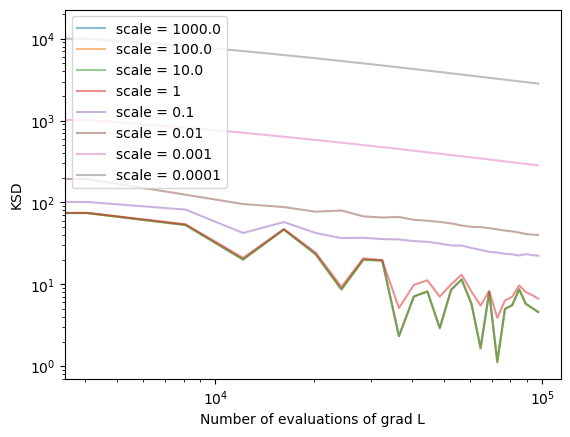

In [188]:
scales = [1e3,1e2,1e1,1,1e-1,1e-2,1e-3,1e-4]
evaluations_grad_L = jnp.arange(0,T) * n_samples

KGD_scales = []
MMD_scales = []
for scale in scales:
    k = lambda x,y : k_imq(x,y,1.,0.5,scale)
    k_pq = GradientKernel(ES.S_PQ,k)
    KGD = KernelGradientDiscrepancy(k_pq)
    k_mmd = lambda x,y : k_imq(x,y,1,0.5,scale)
    KGD_values_l = []
    MMD_values_l = []
    for it in range(T):
        KGD_values_l.append(KGD.evaluate(X_fin[:it+1]))
        if it == 0:
            MMD_values_l.append(MMD(X_fin[:it+2],expe3_results["MFLD contour"]["X_fin"],k_mmd))
        else:
            MMD_values_l.append(MMD(X_fin[:it+1],expe3_results["MFLD contour"]["X_fin"],k_mmd))
    plt.plot(evaluations_grad_L,KGD_values_l,label='scale = '+str(scale),alpha = 0.5)
    KGD_scales.append(jnp.array(KGD_values_l))
    MMD_scales.append(jnp.array(MMD_values_l))
#plt.plot(expe3_results["Extensible Sampling"]["gradL_eval"],expe3_results["Extensible Sampling"]["KGD_values"],label = "ES")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of evaluations of grad L')
plt.ylabel('KSD')
plt.legend()
plt.show()

In [217]:
filename_lengthscales = f"saved_data/kgd_lengthscales_gamma_{gamma}.pkl"

In [218]:
import jax.numpy as jnp
import pickle

# Chargement depuis le fichier
with open(filename_lengthscales, "rb") as g:
    kgd_lengthscales = pickle.load(g)

In [219]:
kgd_lengthscales["Extensible Sampling"]["Scales"] = scales
kgd_lengthscales["Extensible Sampling"]["KGD_scales"] = KGD_scales
kgd_lengthscales["Extensible Sampling"]["MMD_scales"] = MMD_scales

In [ ]:
import pickle

# Save
with open(filename_lengthscales, "wb") as gg:
    pickle.dump(kgd_lengthscales, gg)

Just one lengthscale.

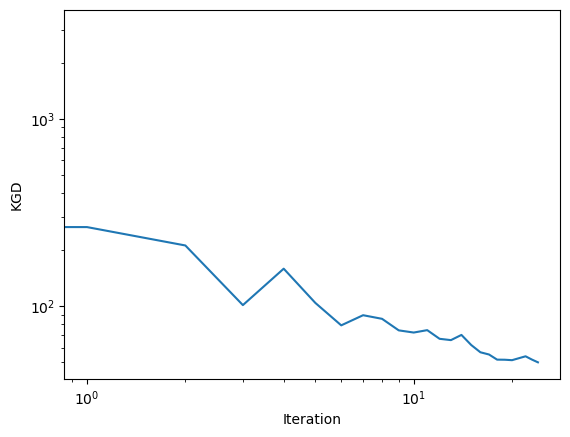

In [ ]:
if kernel_name == "imq":
    scale = 0.1
    k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))
elif kernel_name == "recommended_kernel":
    l = jit(lambda x, y: k_imq(x, y, 1, 0.5,0.1))
    alpha = 2.0
    beta = 1.0
    k = lambda x,y : recommended_kernel(x,y,l,alpha,beta,1.0)

k_pq = GradientKernel(ES.S_PQ,k)
KGD = KernelGradientDiscrepancy(k_pq)

KGD_values = []
for it in range(T):
    KGD_values.append(KGD.evaluate(X_fin[:it+1]))

evaluations_grad_L = jnp.arange(0,T) * n_samples

plt.plot(KGD_values)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('KGD')
plt.show()

# Save results

In [229]:
filename = f"saved_data/expe3_results_gamma_{gamma}_{kernel_name}.pkl"

In [ ]:
import jax.numpy as jnp
import pickle

# load
with open(filename, "rb") as g:
    expe3_results = pickle.load(g)

In [231]:
expe3_results["Extensible Sampling"]["X_fin"] = X_fin
expe3_results["Extensible Sampling"]["KGD_values"] = KGD_values
expe3_results["Extensible Sampling"]["gradL_eval"] = evaluations_grad_L

In [ ]:
import pickle

# Save
with open(filename, "wb") as gg:
    pickle.dump(expe3_results, gg)